In [1]:
import os
import shutil
from pathlib import Path

import pyvista as pv
import ogstools as ot
import ogstools.variables as ov

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from meshing import create_scylindre_mesh
from functions import pd_lsrf_nb, pd_lsrf_fb, find_roots_am, pwd_fsrf_fb, step_rate_r
from functions import scale_and_smooth, pickings

# STIMTEC Example

## Path 2

In [2]:
OGS_PATH = None

if OGS_PATH is not None:
    os.environ["OGS_BIN_PATH"] = OGS_PATH
OUT_DIR = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out_2"))
MESH_DIR = OUT_DIR / "mesh"
shutil.rmtree(OUT_DIR, ignore_errors=True)
MESH_DIR.mkdir(parents=True, exist_ok=True)

## Line/finite-source and step rate

### Pre-procesing and preparing data

In [3]:
cwd=Path.cwd()
newpath=cwd/"STIMTEC_example"
TESTSR= 'BH10_20180718_40.6'
dataex=pd.read_csv(newpath/"BH10_20180718_40.6.csv",sep=",",header=0)

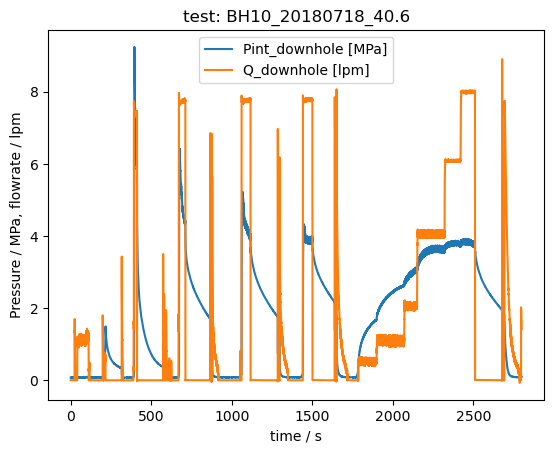

In [4]:
#visualising full data set
#storage correction puphole
su=1/32.664 #(m3/Pa)
dp_dt=np.gradient(dataex['Pint_downhole [MPa]'],dataex['Zeit [s]'])
dataex['Q_downhole [lpm]']=dataex['Q_uphole [lpm]']+dp_dt*su

fig7, ax=plt.subplots()

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa, flowrate / lpm")
plt.title(f"test: {TESTSR}")

ax.plot(dataex['Zeit [s]'],dataex['Pint_downhole [MPa]'],label="Pint_downhole [MPa]")
ax.plot(dataex['Zeit [s]'],dataex['Q_downhole [lpm]'],label="Q_downhole [lpm]")
plt.legend()
plt.show()

steps 	 7


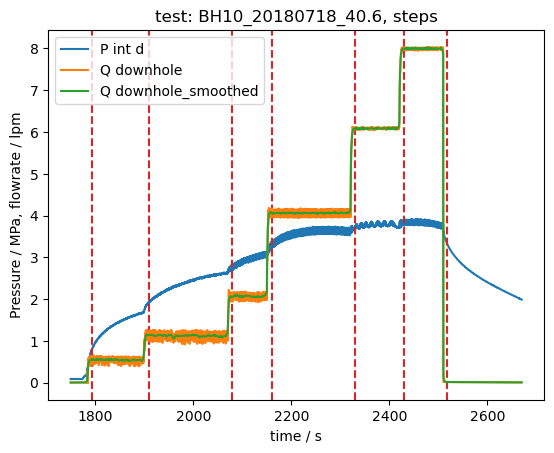

In [5]:
#isolating Step-rate and preparing curve

mask = (dataex['Zeit [s]'] > 1750) & (dataex['Zeit [s]'] <2670)
dataex_f = dataex.loc[mask, :].copy()
dataex_f = dataex_f.reset_index(drop=True)

dataex_f['Q_downhole [lpm]_s']=scale_and_smooth(dataex_f['Q_downhole [lpm]'])

steps_=pickings(dataex_f['Q_downhole [lpm]_s'],40,20)
print('steps','\t', len(steps_))

fig8, ax=plt.subplots()

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa, flowrate / lpm")
plt.title(f"test: {TESTSR}, steps")

ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label="P int d")
for i in range (len(steps_)):
     ax.axvline(x=dataex_f.loc[steps_[i,0],'Zeit [s]'],ls="--",color="tab:red")
ax.plot(dataex_f['Zeit [s]'],dataex_f['Q_downhole [lpm]'],label="Q downhole")
ax.plot(dataex_f['Zeit [s]'],dataex_f['Q_downhole [lpm]_s'],label="Q downhole_smoothed")

plt.legend()
plt.show()
#fig8.savefig(f"{TESTSR}_marks.pdf",format='pdf')

In [6]:
#protocol
pr=pd.DataFrame(data=steps_,
                      index = np.arange(len(steps_)),
                      columns=['index','qs'])
protocol={'index':0,'qs':dataex_f['Q_downhole [lpm]_s'].values[0],'T_s':dataex_f['Zeit [s]'].values[0]}
pr["T_s"]=dataex_f.loc[steps_[:,0].astype(int),'Zeit [s]'].values
protocol=pd.concat([pd.DataFrame(protocol,index=[0]),pr],axis=0)
protocol.reset_index(drop=True, inplace=True)
protocol['qs']=-protocol['qs']/60000 #injection is negative flow

### Finite-source Analytical running

In [7]:
#data 
#average parameters from PPT
Dqp= 6.21e-1 #m**2/s
Tqp= 9.52E-07 #m**2/s
Sqp=1.53E-06  #-
re=8.5       # 8.63 m in reference
h=0.7         # m taken as interval length

c_t=Sqp/(1000*9.8*1.7*0.03)  # Pa-1
c_t=float(f"{c_t:.2e}")
kcal=(Tqp*1e-3)/(1000*9.8*1.7) #m**2
kcal=float(f"{kcal:.2e}")
print(f'Estimated total compressibility: {c_t},{'\n'}Estimated permeability {kcal}')

ddict={"p_i":86316.0,
       "mu":1e-3 ,
       "B":1,
       "por":0.030,
       "c_t":c_t ,
       "r_w":0.038,
       'h': h
      }

delta_t=dataex_f['Zeit [s]'].values
tp=protocol['T_s'].values
q_array=protocol['qs'].values

rinv=np.sqrt(kcal*(tp[-1]-tp[0])/(ddict['por']*ddict['mu']*ddict['c_t']))
print("Investigation radius (m): ",f"{rinv:.2f}",'\n','"Unperturbed" threshold (m): ', f"{4*rinv:.2f}")

Estimated total compressibility: 3.06e-09,
Estimated permeability 5.71e-14
Investigation radius (m):  21.85 
 "Unperturbed" threshold (m):  87.41


In [8]:
#evaluating k around reference
re=re
rw=ddict['r_w']
am= find_roots_am(rw, re,n_roots=1000)

r_val0=ddict['r_w'] #at wellbore face
k_val0= np.geomspace(6e-14, 5e-13, 5) 

pwsr0= step_rate_r(pwd_fsrf_fb, delta_t, tp, q_array, ddict, k_val0, r_val0,re,am)

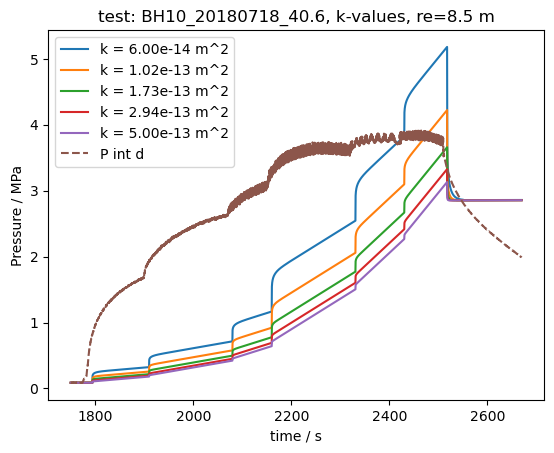

In [9]:
#evaluating k around reference
line_labels9 = [f"k = {val:>5.2e} m^2" for val in k_val0]

fig9, ax=plt.subplots()

ax.plot(delta_t, pwsr0/1e6, label=line_labels9)  
ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label="P int d", ls="--")

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title(f"test: {TESTSR}, k-values, re={re} m")

plt.legend()
plt.show()

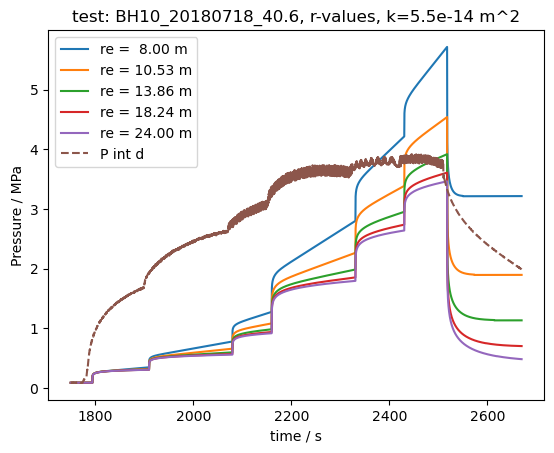

In [10]:
#evaluating re around reference
re1=np.geomspace(8,24,5).round(2) #range of re in reference wellinj to wellmon distance.
rw=ddict['r_w']
am1= find_roots_am(rw, re1,n_roots=1000)

r_val1=ddict['r_w'] #at wellbore face
k_val1= 5.5e-14

pwsr1= step_rate_r(pwd_fsrf_fb, delta_t, tp, q_array, ddict, k_val1, r_val1,re1,am1)

line_labels10 = [f"re = {val:>5.2f} m" for val in re1]
fig10, ax=plt.subplots()

ax.plot(delta_t, pwsr1/1e6, label=line_labels10)   
ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label="P int d", ls="--")

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title(f"test: {TESTSR}, r-values, k={k_val1} m^2")

plt.legend()
plt.show()


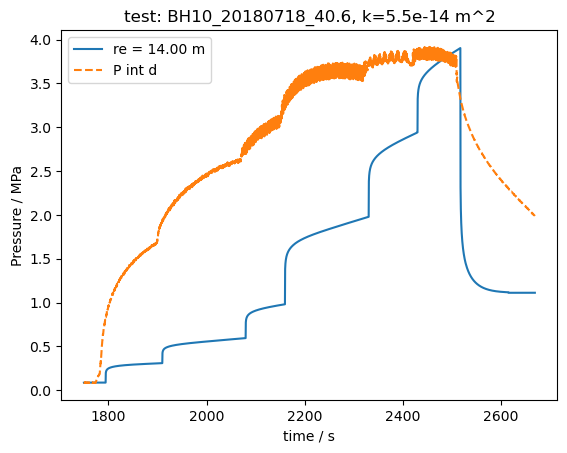

In [11]:
#evaluating best references k and re
re2=14  #range of best re
rw=ddict['r_w']
am2= find_roots_am(rw, re2,n_roots=1000)

r_val2=ddict['r_w'] #at wellbore face
k_val2= k_val1

pwsr2= step_rate_r(pwd_fsrf_fb, delta_t, tp, q_array, ddict, k_val2, r_val2,re2,am2)

fig11, ax=plt.subplots()

ax.plot(delta_t, pwsr2/1e6, label=f're = {re2:.2f} m') 
ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label="P int d", ls="--")

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title(f"test: {TESTSR}, k={k_val2} m^2")

plt.legend()
plt.show()

### Plot Report finite-source

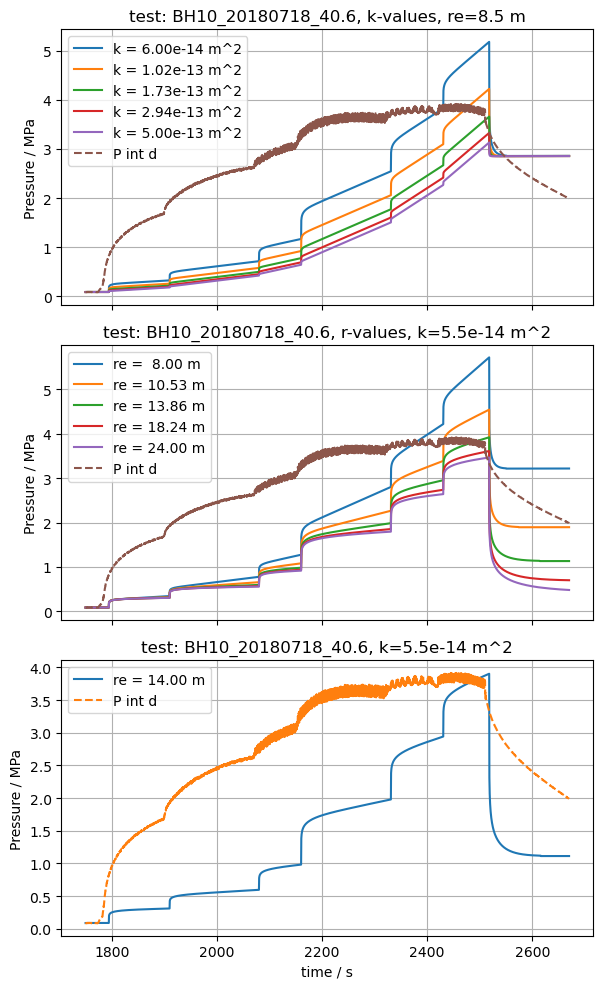

In [12]:
fig12, axs= plt.subplots(nrows=3, ncols=1,figsize=[6,10], sharex=True)


axs[0].plot(delta_t, pwsr0/1e6, label=line_labels9)
axs[0].set_title(f"test: {TESTSR}, k-values, re={re} m")

axs[1].plot(delta_t, pwsr1/1e6, label=line_labels10)
axs[1].set_title(f"test: {TESTSR}, r-values, k={k_val1} m^2")

axs[2].plot(delta_t, pwsr2/1e6, label=f're = {re2:.2f} m') 
axs[2].set_title(f"test: {TESTSR}, k={k_val2} m^2")
axs[2].set_xlabel("time / s")

for i in range (0,3):
    axs[i].plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label="P int d", ls="--")
    axs[i].set_ylabel("Pressure / MPa")
    axs[i].grid()
    axs[i].legend()

plt.tight_layout()
plt.show()
#fig12.savefig(f"fsrfa_fb_2D_{TESTSR}.pdf",format='pdf')

### Line-source Analytical running

With parameters adjusted a wellboreface, $r_\mathrm{w}$ with function of finite source. Now the evaluation carries $r$ variation with line source.

re:14 m 
 k:5.5e-14 m^2 
 r:[ 0.038  0.166  0.729  3.196 14.   ] m


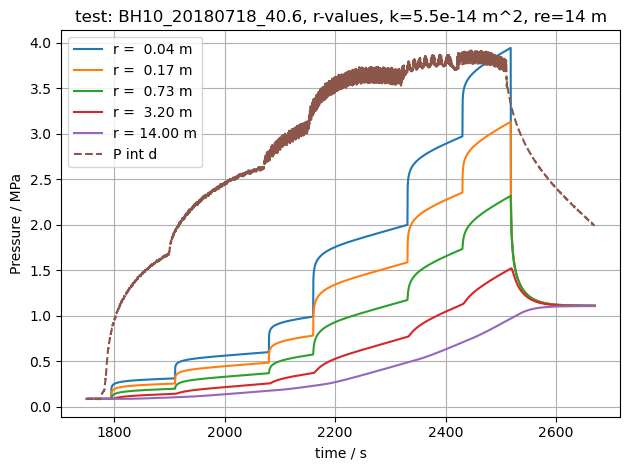

In [13]:
#evaluating best references k and re with varying r to re
re3=re2  #range of best re
rw=ddict['r_w']

r_val3=np.geomspace(ddict['r_w'],re2,5).round(3) 
k_val3= k_val2
print(f're:{re3} m {'\n'} k:{k_val3} m^2 {'\n'} r:{r_val3} m')

pwsr3= step_rate_r(pd_lsrf_fb, delta_t, tp, q_array, ddict, k_val3, r_val3,re3)

line_labels13 = [f"r = {val:>5.2f} m" for val in r_val3]
fig13, ax=plt.subplots()

ax.plot(delta_t, pwsr3/1e6, label=line_labels13)
ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_downhole [MPa]'],label="P int d", ls="--")

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title(f"test: {TESTSR}, r-values, k={k_val3} m^2, re={re3} m")

plt.legend()
plt.tight_layout()
plt.grid()
plt.show()
#fig13.savefig(f"lsrfa_fb_2D_{TESTSR}.pdf",format='pdf') #report figure

## Line/Finite-source Numerical OGS

### Meshing 2D Finite-Source

In [14]:
MSH_FILE = MESH_DIR / "symmetric_cylinder_2D.msh"

r_well=ddict['r_w']
thickness=ddict.get('h', 1.0)  
mesh_size=thickness/4

create_scylindre_mesh( 
        MSH_FILE,
        radius= re3,
        thickness= thickness,
        mesh_size= mesh_size,        #ideal 1/2 of thickness for symmetrical radial application
        r_well= r_well,      # Starting radius (0 for line, >0 for finite well radius in Neumann BC)
        refine_size= 0.05,     # standard 0.1 
        center_y= -40.6
        )

meshes = ot.meshes_from_gmsh(MSH_FILE, log=False)
for name, mesh in meshes.items():
    vtu_path = MESH_DIR / f"rectangle_{name}.vtu"
    pv.save_meshio(vtu_path, mesh)
    print(f"Saved {vtu_path}")


Saved _out_2\mesh\rectangle_domain.vtu
Saved _out_2\mesh\rectangle_physical_group_top.vtu
Saved _out_2\mesh\rectangle_physical_group_boundary_R.vtu
Saved _out_2\mesh\rectangle_physical_group_bottom.vtu
Saved _out_2\mesh\rectangle_physical_group_well.vtu
Saved _out_2\mesh\rectangle_physical_group_domain.vtu


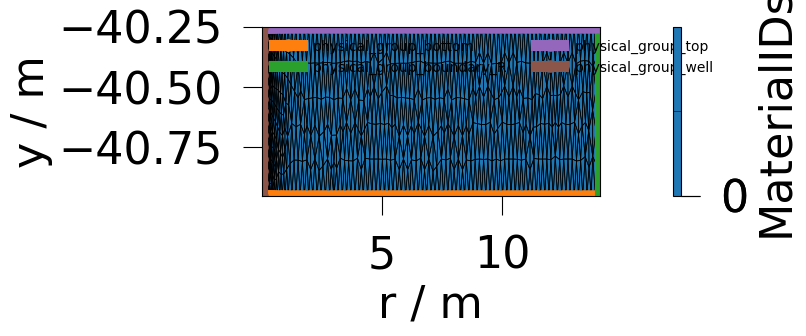

In [15]:
fig14 = meshes["domain"].plot_contourf(
    "MaterialIDs",
    figsize=(8, 6),
    dpi=100,
    cmap="tab20",
    alpha=0.3,
    linewidth=0,
)
ax = fig14.axes[0]
for i, (name, mesh) in enumerate(sorted(meshes.items())):
    if mesh.area:  
        continue
    ls, marker = ("-", "") if "boundary" in name else ("-", "o")
    ot.plot.line(
        mesh,
        ax=ax,
        color=f"C{i}",
        lw=2,
        ls=ls,
        marker=marker,
        markersize=8,
        label=name,
    )
ax.set_xlabel('r / m')
ax.legend(ncol=2, fontsize=10, frameon=False)
plt.show()

### PRJ file pre-procesing

In [16]:
k_ref= k_val3 
ct_ref= ddict["c_t"]*ddict['por'] #OGS storage is scale down by por analytical
print(f'step_rate base {q_array}') #in analytical drawndown positive 

q_fact=-1/(2*np.pi*r_well*ddict['h']) #factor for OGS q*q_fact sign->inj: (+), (-); changing to flux based upon r_well building mesh

step_rate base [-4.99798388e-08 -9.31177407e-06 -1.90106980e-05 -3.41504329e-05
 -6.76589529e-05 -1.01353107e-04 -1.33181916e-04 -2.52184752e-07]


In [17]:
print(re3)

14


In [18]:
PROJECT_BASENAME = "Line_source"
PROJECT_NEW=TESTSR

prj_in = Path(f"{PROJECT_BASENAME}.prj")
prj_out = OUT_DIR/ f"{PROJECT_NEW}_updated.prj"

prj = ot.Project(input_file=prj_in, output_file=prj_out)

In [19]:
root = prj.tree.getroot()
mesh_nodes = root.findall("./meshes/mesh")

if mesh_nodes:
    for mesh_node in mesh_nodes:
        is_axial = mesh_node.get("axially_symmetric")
        
        if is_axial != "true":
            mesh_node.set("axially_symmetric", "true")
            print(f"Added axial symmetry to: {mesh_node.text}")
        else:
            print(f"Axial symmetry already active for: {mesh_node.text}")
else:
    print("Error: No <mesh> tags found in the <meshes> section.")

Added axial symmetry to: rectangle_domain.vtu
Added axial symmetry to: rectangle_physical_group_bottom.vtu
Added axial symmetry to: rectangle_physical_group_top.vtu
Added axial symmetry to: rectangle_physical_group_well.vtu
Added axial symmetry to: rectangle_physical_group_boundary_R.vtu


In [20]:
boundary_condition='no_flow_boundary' #options: infinite, no_flow_boundary, pressure_boundary
target_mesh = "rectangle_physical_group_boundary_R"

def mesh_condition(boundary,target,ddict=ddict):
    xpath=f"./process_variables/process_variable/boundary_conditions/boundary_condition[mesh='{target}']/type"
    bc={"infinite":'Dirichlet',"no_flow_boundary":'Neumann', "pressure_boundary":'Dirichlet'}

    if boundary in bc:
        prj.replace_text(bc[boundary], xpath=xpath)
        print(f"Updated {target} to {bc[boundary]}")
        
        if boundary=='no_flow_boundary':
            prj.replace_parameter_value(name="pi_bd", value=0)
            value_r=0
        else:
            prj.replace_parameter_value(name="pi_bd", value=ddict["p_i"]) 
            value_r=ddict["p_i"]
        print(f"Updated {target} value to {value_r}") 
    else:
        print(f"Error: '{boundary}' is not a valid boundary option.") 

try:
    mesh_condition(boundary_condition,target_mesh)
    
    prj.replace_parameter_value(name="p0", value=ddict["p_i"])

    mid=0
    prj.replace_phase_property_value(mediumid=mid, phase="AqueousLiquid", name="viscosity", value=ddict["mu"])
    
    prj.replace_medium_property_value(mediumid=mid, name="porosity", value=ddict["por"])
    prj.replace_medium_property_value(mediumid=mid, name="permeability", value=k_ref)
    prj.replace_medium_property_value(mediumid=mid, name="storage", value= ct_ref)

    print("media/properties, Parameters updated")
except Exception as e:
    print(f"Error occurred: {e}")

Updated rectangle_physical_group_boundary_R to Neumann
Updated rectangle_physical_group_boundary_R value to 0
media/properties, Parameters updated


In [21]:
last_t=dataex_f.loc[dataex_f.tail(1).index.values.astype(int),'Zeit [s]':'Q_downhole [lpm]']
last_t['Q_downhole [lpm]']=last_t['Q_downhole [lpm]']/60000
last_t=last_t.values.flatten().tolist() 
print(f'"Last-step" {last_t}')

param_name = "q_in" #inlet flow

def create_sr_ogs(T,q,data,factor=q_fact,var="t"): #factor carries the convention: production = q*factor (-), injection (+)
        
    q_scaled = q * factor
    q_last_scaled = data[1] * factor 
    
    q_list = q_scaled.tolist()
    q_list.append(q_last_scaled)
    
    T_list = T.tolist()
    T_list.append(data[0])
        
    parts = [f"{var} < {T_list[i+1]:g} ? {q_list[i]:.6g} :" for i in range(0, len(T_list)-1)]
    
    return "(" + "\n           ".join(parts) + f"\n           {q_list[-1]:.6g})",T_list
    
def set_adaptive_stepping(prj, t_start, t_end, initial_dt=1, min_dt=0.5,max_dt=10):
    try:
        prj.remove_element(xpath="./time_loop/processes/process/time_stepping")
    except:
        pass 
        
    iterations = "1 3 5 8 10"
    multipliers = "1.5 1.2 1.0 0.8 0.5"
    
    prj.add_block("time_stepping", 
                  parent_xpath="./time_loop/processes/process", 
                  taglist=[
                      "type",
                      "t_initial", 
                      "t_end", 
                      "initial_dt", 
                      "minimum_dt", 
                      "maximum_dt", 
                      "number_iterations",
                      "multiplier"
                          ],
                  textlist=["IterationNumberBasedTimeStepping",
                            str(t_start),
                            str(t_end),
                            str(initial_dt),
                            str(min_dt),
                            str(max_dt),
                            iterations,
                            multipliers
                           ]
                  )
    
    print(f"Adaptive stepping set: {t_start} to {t_end} (Max Δt: {max_dt})")

try:  
    root = prj.tree.getroot() # Access the underlying ElementTree
    param_node = root.find(f".//parameters/parameter[name='{param_name}']")
    value_tag = param_node.find("value")
    if value_tag is not None:
         param_node.remove(value_tag)
    
    n_type = prj.replace_text(
        "Function", xpath=f".//parameters/parameter[name='{param_name}']/type"
    )
    
    n_expr,Times = create_sr_ogs(tp,q_array,last_t)
    
    prj.add_element(
        parent_xpath=f".//parameters/parameter[name='{param_name}']", 
        tag="expression", 
        text=n_expr
    )
    
    print("flow_expression", n_expr)
    
    #timestepping calculations 
    max_dt=10
    set_adaptive_stepping(prj, Times[0], Times[-1], max_dt=max_dt)

    #out and prefix
    outsteps=1 #10 at convenience
    prefix= TESTSR
    
    prj.replace_text("1",
                     xpath="./time_loop/output/timesteps/pair/repeat")
    prj.replace_text(outsteps, #resolution of stepping
                    xpath="./time_loop/output/timesteps/pair/each_steps")
    prj.replace_text(prefix, 
                     xpath="./time_loop/output/prefix")
    
    print("ouput_res: ", outsteps,'\n','prefix:',prefix )
    
except Exception as e:
    
    print(f"Error occurred: {e}")

prj.write_input()
print('\n', f"prj update in {prj_out} as {PROJECT_NEW}_updated.prj")

"Last-step" [2669.809, 0.006152, 9.957901053148818e-08]
flow_expression (t < 1794.21 ? 2.99043e-07 :
           t < 1909.81 ? 5.57148e-05 :
           t < 2079.81 ? 0.000113746 :
           t < 2160.01 ? 0.000204331 :
           t < 2330.81 ? 0.000404822 :
           t < 2430.41 ? 0.000606423 :
           t < 2517.81 ? 0.000796863 :
           t < 2669.81 ? 1.50889e-06 :
           -0.0368091)
Adaptive stepping set: 1750.009 to 2669.809 (Max Δt: 10)
ouput_res:  1 
 prefix: BH10_20180718_40.6

 prj update in _out_2\BH10_20180718_40.6_updated.prj as BH10_20180718_40.6_updated.prj


### Running OGS

In [22]:
!ogs ./_out_2/BH10_20180718_40.6_updated.prj -m ./_out_2/mesh -o ./_out_2

info: This is OpenGeoSys-6 version 6.5.5.
info: OGS started on 2026-04-01 11:12:06+0200.
info: Eigen use 16 threads
info: Reading project file _out_2\BH10_20180718_40.6_updated.prj.
info: readRasters ...
info: readRasters done
info: ConstantParameter: p0
info: ConstantParameter: p_tb
info: ConstantParameter: pi_bd
info: ConstantParameter: constant_porosity_parameter
info: FunctionParameter: q_in
info: No source terms for process variable 'pressure' found.
info: Initialize processes.
info: Time step #0 started. Time: 1750.009. Step size: 0.
info: [time] Output of timestep 0 took 0.0131019 s.
info: Time step #0 took 0.0153353 s.
info: OpenGeoSys is now initialized.
info: OGS started on 2026-04-01 11:12:06+0200.
info: Solve processes.
info: Time step #1 started. Time: 1751.009. Step size: 1.
info: Solving process #0 started.
info: Iteration #1 started.
info: [time] Assembly took 0.0043472 s.
info: [time] Applying Dirichlet BCs took 8.95e-05 s.
info: ---------------------------------------

## Results and visualization

### Post-processing

In [23]:
pvd_path1 = Path("_out_2/BH10_20180718_40.6.pvd")
ms1 = ot.MeshSeries(pvd_path1)
pressure=ot.variables.pressure
pressure= pressure.replace(output_unit="MPa")

In [24]:
y=-40.6
r_st1=ddict['r_w']
r_en1=re3

coords=np.array(np.geomspace([r_st1,y,1e-18],[r_en1,y,1e-18],5).round(3)) 
ms_probes1 = ms1.extract_probe(ms1,points=coords)

labels1 = [f"r={pt[0]:>5.3f}, y={y}" for pt in coords]
print(f'midpoint along well: {y}m {'\n'}wellbore radius: {r_st1} m, {'/n'}Boundary (aprox) distance: {r_en1} m')
print(f'r to evaluate: {coords[:,0]} m')

timeogs1=ms_probes1.timevalues
pwsr3p= step_rate_r(pd_lsrf_fb, timeogs1 , tp, q_array, ddict, k_val3, r_val3,re3)
diff1 = pwsr3p - ms_probes1['pressure']


100%|██████████████████████████████████████████████████████████████████████████████████| 97/97 [00:01<00:00, 65.03it/s]


midpoint along well: -40.6m 
wellbore radius: 0.038 m, /nBoundary (aprox) distance: 14 m
r to evaluate: [ 0.038  0.166  0.729  3.196 14.   ] m


### Analytical and Numerical OGS comparison

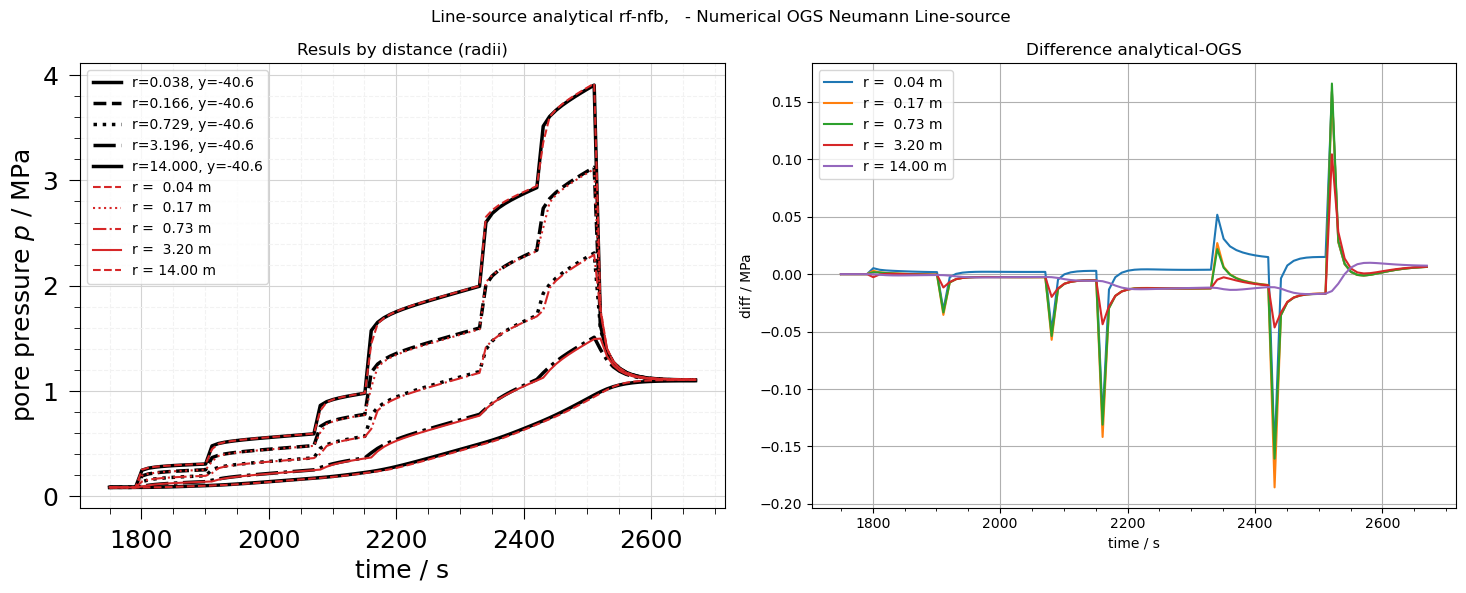

In [25]:
fig15, axs= plt.subplots(nrows=1, ncols=2,figsize=[15,6], sharex=True)
ot.plot.line(ms_probes1,"time", pressure,ax=axs[0], color='k',fontsize=18,label=labels1)
axs[0].plot(timeogs1, pwsr3p/1e6,color='tab:red', label=line_labels13) 
axs[1].plot(timeogs1, diff1/1e6, label=line_labels13)

fig15.suptitle("Line-source analytical rf-nfb,   - Numerical OGS Neumann Line-source") 
axs[0].set_title("Resuls by distance (radii)")
axs[1].set_title("Difference analytical-OGS")

axs[1].set_xlabel("time / s")
axs[1].set_ylabel("diff / MPa")

axs[0].legend()
axs[1].legend()
axs[1].grid()
plt.tight_layout()

plt.show()
#fig15.savefig(f"lsrfn_fb_2D_{TESTSR}.pdf",format='pdf') #report figure

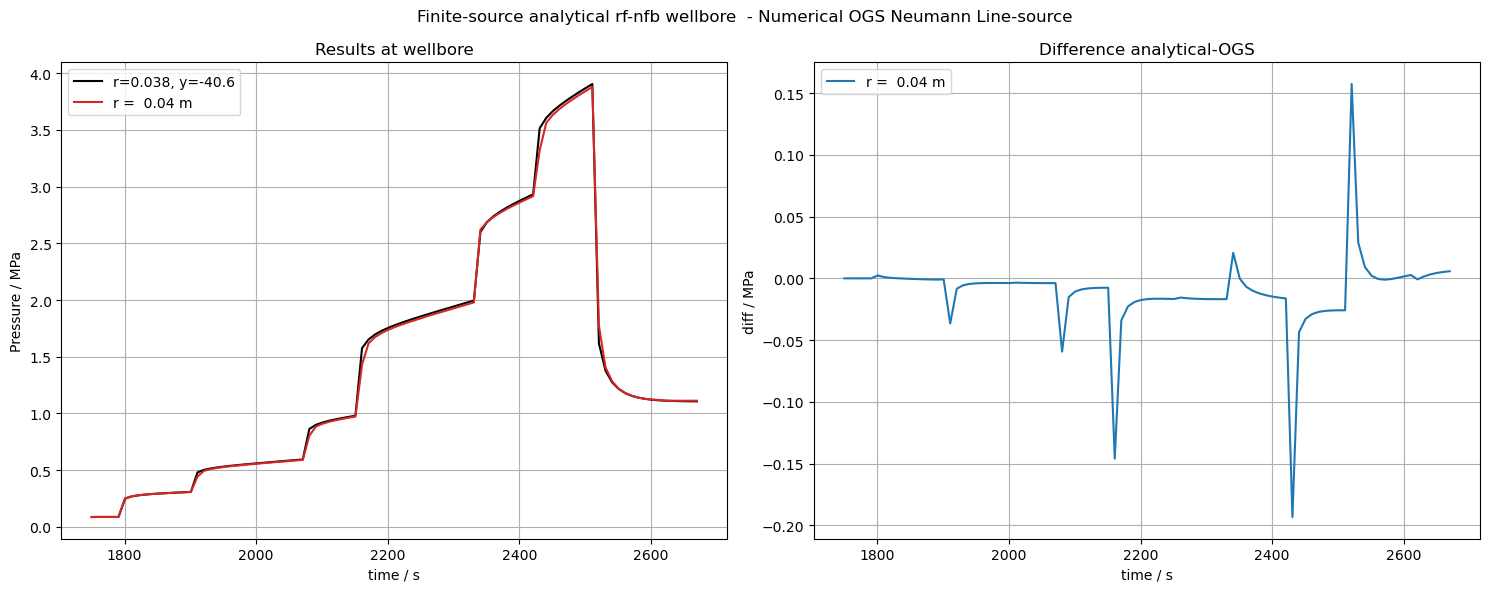

In [26]:
#Pwd finite source vs OGS STIMTEC
pw2= step_rate_r(pwd_fsrf_fb, timeogs1, tp, q_array, ddict, k_val2, r_val2,re2,am2)
ms_probes1_w=ms_probes1['pressure'][0:,0]
diff2 = pw2-ms_probes1_w

fig16, axs= plt.subplots(nrows=1, ncols=2,figsize=[15,6], sharex=True)
axs[0].plot(timeogs1,ms_probes1_w/1e6, color='k',label=labels1[0])
axs[0].plot(timeogs1, pw2/1e6,color='tab:red', label=line_labels13[0]) 
axs[1].plot(timeogs1, diff2/1e6, label=line_labels13[0])

fig16.suptitle("Finite-source analytical rf-nfb wellbore  - Numerical OGS Neumann Line-source") 
axs[0].set_title("Results at wellbore")
axs[1].set_title("Difference analytical-OGS")

axs[0].set_xlabel("time / s")
axs[0].set_ylabel("Pressure / MPa")
axs[1].set_xlabel("time / s")
axs[1].set_ylabel("diff / MPa")

axs[0].legend()
axs[0].grid()
axs[1].legend()
axs[1].grid()
plt.tight_layout()
plt.show()
#fig16.savefig(f"fsrfn_fb_2D_{TESTSR}.pdf",format='pdf') #report figure